In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [6]:
# 0. Definição e Carregamento de todas as bases de dados
# (Certifique-se de que os arquivos .csv estão na mesma pasta do seu notebook)
pd.read_csv ('canais_venda.csv', sep=';')
pd.read_csv ('clientes.concat.csv', sep=';')
pd.read_csv ('funcionarios.concat.csv', sep=';')
pd.read_csv ('reservas.concat.corrigido.csv', sep=';')
pd.read_csv ('tipos_quarto.concat.csv', sep=';')
pd.read_csv ('unidades.concat.csv', sep=';')

,id_unidade,nome_unidade,cidade,regiao,categoria_hotel(estrelas),num_quartos_total
0,1,NaraHoteis Ipanema,Rio de Janeiro,Capital,5,80
1,2,NaraHoteis Barra da Tijuca,Rio de Janeiro,Capital,4,120
2,3,NaraHoteis Centro,Rio de Janeiro,Capital,3,60
3,4,NaraHoteis Santa Teresa,Rio de Janeiro,Capital,4,45
4,5,NaraHoteis Nova Iguaçu Centro,Nova Iguaçu,Baixada Fluminense,3,50
5,6,NaraHoteis Nova Iguaçu Park,Nova Iguaçu,Baixada Fluminense,3,55
6,7,NaraHoteis Petrópolis,Petrópolis,Serra,5,70
7,8,NaraHoteis Teresópolis,Teresópolis,Serra,4,60
8,9,NaraHoteis Friburgo,Nova Friburgo,Serra,4,55
9,10,NaraHoteis Paraty,Paraty,Costa Verde,5,75


In [7]:
import pandas as pd

# 1. Carregando as bases com os nomes atualizados
df_reservas = pd.read_csv('reservas.concat.corrigido.csv', sep=';')
df_tipos_quarto = pd.read_csv('tipos_quarto.concat.csv', sep=';')
df_unidades = pd.read_csv('unidades.concat.csv', sep=';')

# Bases extras carregadas para as próximas etapas do painel
df_canais_venda = pd.read_csv('canais_venda.csv', sep=';')
df_clientes = pd.read_csv('clientes.concat.csv', sep=';')
df_funcionarios = pd.read_csv('funcionarios.concat.csv', sep=';')

# 2. Executando o cruzamento da Pergunta 3
df_merged = df_reservas.merge(df_tipos_quarto[['id_tipo_quarto', 'valor_diaria_base']], on='id_tipo_quarto', how='left')
df_merged = df_merged.merge(df_unidades[['id_unidade', 'nome_unidade', 'regiao']], on='id_unidade', how='left')
df_merged['faturamento_reserva'] = df_merged['qtd_diarias'] * df_merged['valor_diaria_base']

print("Bases carregadas e cruzamento realizado com sucesso!")

Bases carregadas e cruzamento realizado com sucesso!


In [8]:
# 1. Cruzando reservas, tipos de quarto e unidades para obter o faturamento por reserva e a região
df_p6 = df_reservas.merge(df_tipos_quarto[['id_tipo_quarto', 'valor_diaria_base']], on='id_tipo_quarto', how='left')
df_p6 = df_p6.merge(df_unidades[['id_unidade', 'regiao', 'nome_unidade']], on='id_unidade', how='left')
df_p6['faturamento'] = df_p6['qtd_diarias'] * df_p6['valor_diaria_base']



In [9]:
# 2. Calculando estatísticas de variabilidade do faturamento por região
resumo_regiao = df_p6.groupby('regiao')['faturamento'].agg(['count', 'mean', 'median', 'std', 'max', 'min']).reset_index()
resumo_regiao.columns = ['Região', 'Qtd Reservas', 'Média', 'Mediana', 'Desvio Padrão', 'Máximo', 'Mínimo']
resumo_regiao = resumo_regiao.sort_values(by='Desvio Padrão', ascending=False)

display(resumo_regiao)



,Região,Qtd Reservas,Média,Mediana,Desvio Padrão,Máximo,Mínimo
3,Serra,1058,2459.593573,1740.0,2021.601350,10500.0,280.0
2,Costa Verde,1091,2399.248396,1740.0,1972.841146,12000.0,280.0
1,Capital,1730,1902.184971,1400.0,1657.841025,10500.0,280.0
0,Baixada Fluminense,770,1659.181818,1120.0,1647.980750,10500.0,280.0


C:\Users\Robert\AppData\Local\Temp\ipykernel_6168\2116428303.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_p6, x='regiao', y='faturamento', palette='Set2')


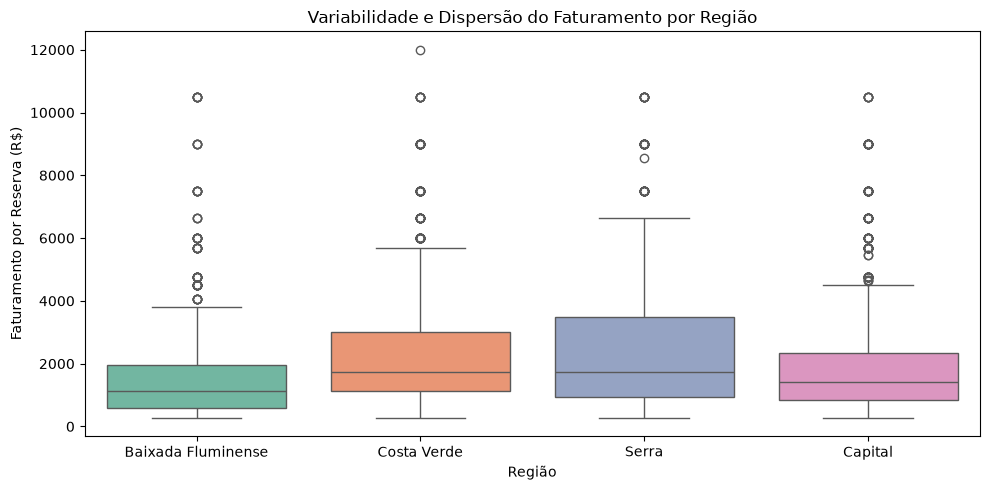

In [10]:
# 3. Visualização Gráfica: Boxplot do Faturamento por Região
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_p6, x='regiao', y='faturamento', palette='Set2')
plt.title('Variabilidade e Dispersão do Faturamento por Região')
plt.xlabel('Região')
plt.ylabel('Faturamento por Reserva (R$)')
plt.tight_layout()
plt.show()

PERGUNTA 6

Qual região apresenta maior variabilidade no faturamento? O que isso pode indicar para a gestão comercial?

RESPOSTA

A região que apresenta a maior variabilidade no faturamento da rede é a Serra, registrando o maior desvio padrão (R$ 2.021,60), acompanhada de perto pela Costa Verde (desvio padrão de R$ 1.972,84).

Esta dispersão é estatisticamente comprovada pela enorme amplitude dos valores praticados nessas regiões: enquanto o valor mínimo das reservas é de R$ 280,00, os limites máximos alcançam R$ 10.500,00 na Serra e o pico de R$ 12.000,00 na Costa Verde.

Serra e Costa Verde pedem ousadia nas vendas. Como essas regiões apresentam picos enormes de faturamento (com reservas batendo R$ 10 mil a R$ 12 mil), o cliente ali está disposto a gastar por boas experiências. A equipe deve apostar forte no upsell — oferecer a suíte superior no momento do check-in, vender pacotes premium de feriados e focar no luxo, sem medo de cobrar mais caro.

A Capital exige eficiência e giro rápido. A variação de preço é menor, mas o volume de reservas é gigante. O hóspede tem um perfil mais prático, provavelmente viajando a trabalho ou por pouco tempo. A estratégia aqui não é tentar empurrar pacotes caros, mas manter uma precificação competitiva e ágil para garantir que o hotel esteja sempre cheio, ganhando na constância e no volume.

A Baixada Fluminense precisa de novos atrativos. Com a menor média de gastos e quase nenhuma variação, fica claro que o cliente consome estritamente o quarto básico e vai embora. Para destravar mais receita nessa praça, a equipe comercial precisa ser criativa: criar pacotes românticos de fim de semana, oferecer opções de day-use na piscina ou vender combos com alimentação para estimular esse hóspede a gastar um pouco além da diária normal.